In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/musait/tsa_evaluation_results.json
/kaggle/input/musait/gcv-ocr.csv
/kaggle/input/musait/vsa_expt_results.json
/kaggle/input/musait/dataset/Dataset/Small/Test/neutral/neutral6.jpg
/kaggle/input/musait/dataset/Dataset/Small/Test/neutral/neutral12.jpg
/kaggle/input/musait/dataset/Dataset/Small/Test/neutral/neutral7.jpg
/kaggle/input/musait/dataset/Dataset/Small/Test/neutral/neutral15.jpg
/kaggle/input/musait/dataset/Dataset/Small/Test/neutral/neutral2.jpg
/kaggle/input/musait/dataset/Dataset/Small/Test/neutral/neutral11.jpg
/kaggle/input/musait/dataset/Dataset/Small/Test/neutral/neutral8.jpg
/kaggle/input/musait/dataset/Dataset/Small/Test/neutral/neutral14.jpg
/kaggle/input/musait/dataset/Dataset/Small/Test/neutral/neutral1.jpg
/kaggle/input/musait/dataset/Dataset/Small/Test/neutral/neutral10.jpg
/kaggle/input/musait/dataset/Dataset/Small/Test/neutral/neutral4.jpg
/kaggle/input/musait/dataset/Dataset/Small/Test/neutral/neutral13.jpg
/kaggle/input/musait/dataset/Dataset/Smal

In [ ]:
# Install necessary packages
!pip install -q ftfy regex tqdm torch torchvision timm

# Exit any current Jupyter execution (optional if needed)
import os
import sys
os._exit(0)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.7 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 106.2 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 79.9 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 46.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.3 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 3.6 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 3.4 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 13.4 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 8.1 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 69.9 MB/s eta 0:00:00:00:0100:01


In [2]:
# ======================= #
#     STEP 1: IMPORTS     #
# ======================= #
# Install timm for ViT-L
# !pip install -q timm

# Imports
import os
import pandas as pd
import torch
import timm
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score
import torch.nn as nn
import torch.optim as optim
from tqdm.notebook import tqdm


In [3]:
from torch.utils.data import Dataset
from PIL import Image
import pandas as pd
import os

class CustomImageDataset(Dataset):
    def __init__(self, csv_file, img_dir, preprocess, label_encoder):
        self.data = pd.read_csv(csv_file)
        self.img_dir = img_dir
        self.preprocess = preprocess
        self.label_encoder = label_encoder
        self.data['sentiment'] = self.label_encoder.fit_transform(
            self.data['sentiment'].str.lower().str.strip()
        )

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row = self.data.iloc[idx]
        img_path = os.path.join(self.img_dir, row['filename'])
        image = Image.open(img_path).convert("RGB")
        image = self.preprocess(image)
        label = row['sentiment']
        return image, label


In [4]:
import torchvision.transforms as transforms

preprocess = transforms.Compose([
    transforms.Resize((224, 224)),  # Resize to match ViT-L/16 input
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.5, 0.5, 0.5],        # Can also use [0.485, 0.456, 0.406]
        std=[0.5, 0.5, 0.5]          # or [0.229, 0.224, 0.225] for ImageNet
    )
])


In [5]:
# os.listdir("/kaggle/input/basket")
import os

temp_data = pd.DataFrame(columns=["filename","label"])
all_files = os.listdir("/kaggle/input/musait/dataset/basket")
all_files.sort()

In [6]:
import os

temp_data = pd.DataFrame(columns=["filename","sentiment"])
all_files = os.listdir("/kaggle/input/musait/dataset/basket")
all_files.sort()

for file in all_files:
    label = file.split("_")[0]
    # print(label)
    # print(file)
    temp_data = pd.concat([temp_data, pd.DataFrame([[file, label]], columns=["filename", "sentiment"])], ignore_index=True)
    # print(temp_data)
    # break

# Optional: Display the DataFrame
print(temp_data.head())

           filename sentiment
0  negative_001.jpg  negative
1  negative_002.jpg  negative
2  negative_003.jpg  negative
3  negative_004.jpg  negative
4  negative_005.jpg  negative


In [7]:
temp_data.to_csv("temp_data.csv", index=False)

In [8]:
import timm
import torchvision.transforms as transforms

# Device
device = "cuda" if torch.cuda.is_available() else "cpu"

num_classes = 3

# Load ViT-L/16 model from timm
vit_model = timm.create_model("vit_large_patch16_224", pretrained=True)
vit_model.head = nn.Linear(vit_model.head.in_features, num_classes)  # Replace head for classification
vit_model = vit_model.to(device)

# Preprocessing (matching ViT input expectations)
preprocess = transforms.Compose([
    transforms.Resize((224, 224)),  # Resize to ViT-L input
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.5, 0.5, 0.5],  # or [0.485, 0.456, 0.406] for ImageNet
        std=[0.5, 0.5, 0.5]    # or [0.229, 0.224, 0.225]
    )
])

model.safetensors:   0%|          | 0.00/1.22G [00:00<?, ?B/s]

In [9]:
temp_data

,filename,sentiment
0,negative_001.jpg,negative
1,negative_002.jpg,negative
2,negative_003.jpg,negative
3,negative_004.jpg,negative
4,negative_005.jpg,negative
...,...,...
2870,positive_995.jpg,positive
2871,positive_996.jpg,positive
2872,positive_997.jpg,positive
2873,positive_998.jpg,positive


In [10]:
# Freeze ViT-L parameters (like you did with CLIP)
for param in vit_model.parameters():
    param.requires_grad = False

# Label encoder
le = LabelEncoder()

# Dataset and DataLoader
csv_path = "/kaggle/working/temp_data.csv"
img_dir = "/kaggle/input/musait/dataset/basket"

dataset = CustomImageDataset(csv_path, img_dir, preprocess, le)

# Split into train, val, test
from torch.utils.data import random_split
train_size = int(0.8 * len(dataset))
val_size = int(0.1 * len(dataset))
test_size = len(dataset) - train_size - val_size

train_ds, val_ds, test_ds = random_split(dataset, [train_size, val_size, test_size])

train_loader = DataLoader(train_ds, batch_size=16, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=16, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=16, shuffle=False)


In [11]:
# Get one batch from the dataloader
images, labels = next(iter(train_loader))

print("Images shape:", images.shape)
print("Labels shape:", labels.shape)
print("Labels:", labels)

Images shape: torch.Size([16, 3, 224, 224])
Labels shape: torch.Size([16])
Labels: tensor([1, 0, 0, 2, 2, 1, 0, 0, 2, 1, 0, 2, 0, 1, 1, 2])


In [12]:
# Image encoder is the full ViT model (since we froze it already)
image_encoder = vit_model

# Define classifier for ViT-L
class ViTClassifier(nn.Module):
    def __init__(self, encoder, embed_dim, num_classes):
        super().__init__()
        self.encoder = encoder
        self.classifier = nn.Linear(embed_dim, num_classes)

    def forward(self, image):
        with torch.no_grad():
            x = self.encoder.forward_features(image)
        # If x is [B, 197, 1024], take only CLS token: x[:, 0, :]
        if x.dim() == 3:
            x = x[:, 0, :]  # Take CLS token
        x = x.float()
        return self.classifier(x)  # ✅ NO softmax here


# ViT-L/16 has 1024-dimensional final embedding
model = ViTClassifier(image_encoder, embed_dim=1024, num_classes=3).to(device)


In [13]:
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import torch

# Early stopping and tracking setup
best_val_loss = float('inf')
patience = 3
counter = 0
train_losses = []
val_losses = []

# Loss and optimizer (ViT classifier layer only)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.classifier.parameters(), lr=1e-4)

# Training loop
for epoch in range(10):  # You can increase this
    model.train()
    train_loss = 0.0

    for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1} - Training"):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        # print("Output shape:", outputs.shape)
        # print("Label shape:", labels.shape)

        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    train_loss /= len(train_loader)
    train_losses.append(train_loss)

    # Validation loop
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for images, labels in tqdm(val_loader, desc=f"Epoch {epoch+1} - Validation"):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()

    val_loss /= len(val_loader)
    val_losses.append(val_loss)

    print(f"Epoch {epoch+1}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")

    # Early stopping
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), "best_vit_model.pt")
        print("✅ Model saved.")
        counter = 0
    else:
        counter += 1
        if counter >= patience:
            print("⛔ Early stopping triggered.")
            break


Epoch 1 - Training:   0%|          | 0/144 [00:00<?, ?it/s]

/usr/local/lib/python3.11/dist-packages/PIL/Image.py:1043: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch 1 - Validation:   0%|          | 0/18 [00:00<?, ?it/s]

Epoch 1, Train Loss: 0.9869, Val Loss: 0.6937
✅ Model saved.


Epoch 2 - Training:   0%|          | 0/144 [00:00<?, ?it/s]

...

Epoch 9 - Validation:   0%|          | 0/18 [00:00<?, ?it/s]

Epoch 9, Train Loss: 0.2848, Val Loss: 0.4031
✅ Model saved.


Epoch 10 - Training:   0%|          | 0/144 [00:00<?, ?it/s]

Epoch 10 - Validation:   0%|          | 0/18 [00:00<?, ?it/s]

Epoch 10, Train Loss: 0.2658, Val Loss: 0.4122


In [14]:
best_val_loss

0.40306922503643566

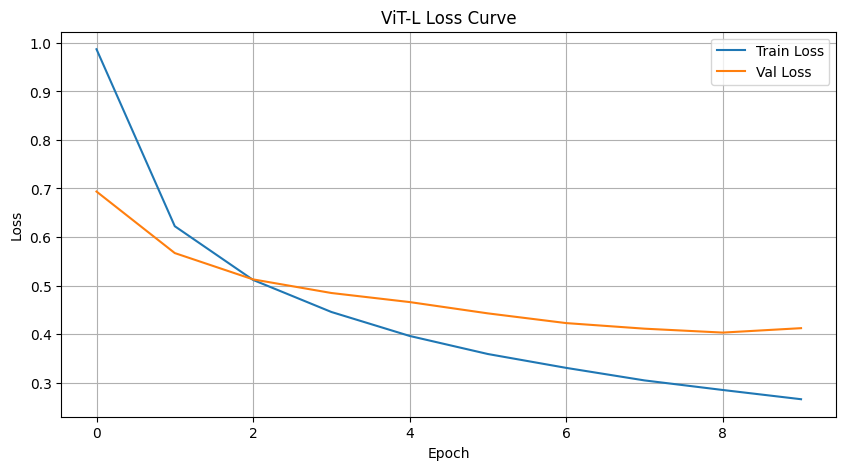

In [15]:
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('ViT-L Loss Curve')
plt.legend()
plt.grid(True)
plt.savefig("ViT-L__loss_curve.png")
plt.show()


In [16]:
# Load best model
model.load_state_dict(torch.load("best_vit_model.pt"))
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in tqdm(test_loader, desc="Inference"):
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        preds = outputs.argmax(dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Decode labels
class_names = le.classes_

# Accuracy
acc = accuracy_score(all_labels, all_preds)
print(f"🎯 Test Accuracy: {acc * 100:.2f}%")

# Classification Report
report = classification_report(all_labels, all_preds, target_names=class_names)
print(report)

# Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)

import json

metrics = {
    "training_loss" : 0.3416,
    "validation_loss" : best_val_loss,
    "test_accuracy": round(acc * 100, 2),
    "classification_report": report,  # This is already a string
    "confusion_matrix": cm.tolist()   # Convert NumPy array to list for JSON
}

with open("test_metrics.json", "w") as f:
    json.dump(metrics, f, indent=4)


Inference:   0%|          | 0/18 [00:00<?, ?it/s]

🎯 Test Accuracy: 82.99%
              precision    recall  f1-score   support

    negative       0.81      0.87      0.84        84
     neutral       0.79      0.76      0.77        88
    positive       0.88      0.85      0.86       116

    accuracy                           0.83       288
   macro avg       0.83      0.83      0.83       288
weighted avg       0.83      0.83      0.83       288

